# Lecture 1 Demo: One Image, End to End

**Instructor demo.** Runs in about fifteen seconds with no external files.

The claim on the slides is that every stage of a camera throws information away and nothing
downstream gets it back. This notebook makes that concrete by building a scene whose true
radiance we know exactly, pushing it through a simulated camera, and then trying to recover it.

Because the ground truth is synthetic, we can measure precisely what was lost. With a real
photograph you never can, which is itself worth saying out loud in class.

**The three points to make:**

1. The sensor measures **one color per pixel**. Two thirds of the color image is interpolated.
2. The image signal processor is a **chain of choices**, not a formula. Change the order and you get a different photograph.
3. A pipeline tuned for a human is **not** tuned for a machine, and neither one is "correct."

If you have a real raw file, the last section swaps it in.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

rng = np.random.default_rng(513)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.grid": False,
    "image.interpolation": "nearest",
})

PSU_GREEN, PSU_BLUE = "#4f7018", "#0f6f96"
print("OpenCV", cv2.__version__)

OpenCV 5.0.0


## 1. A scene we know exactly

Three targets, chosen because they are the three things Project 1 measures: a color chart for
color accuracy, a slanted edge for spatial resolution, and a frequency sweep to show aliasing.

**Why an edge measures resolution.** Resolution is the system's frequency response, so what we
actually need is its impulse response. A point source cannot be photographed: it is smaller
than a pixel and far too dim. An edge gives us a step instead, and a step is bright and trivial
to build. Image the edge, differentiate the result, and that derivative is the impulse response
projected along the edge direction; the magnitude of its Fourier transform is the MTF. Step
response to impulse response to frequency response, the same move as in any other system
identification problem.

**Why it is slanted.** A perfectly vertical edge is sampled at the same sub-pixel phase in
every row, so a thousand rows give you the same handful of points on the edge profile, spaced
one pixel apart. That is far too coarse for a transition only a few pixels wide. Tilt the edge
by 5 degrees and each row's crossing shifts by tan(5 deg) = 0.0875 pixels, so about eleven rows
walk one full pixel of phase. Project every row onto the edge normal and the same profile is
now sampled roughly eleven times finer than the pixel grid. The tilt dithers the sampling phase
in space, which is what lets us evaluate the MTF above Nyquist, exactly where aliasing lives.
The `0.0875` in `build_scene` below is that tangent.

This is the ISO 12233 slanted-edge method, and lecture 4 turns it into a number. Today it is
enough to point at the edge and say that resolution is something you measure, not something you
read off a spec sheet. The colored fringes along that same edge in section 7 are a different
defect: demosaicing, not blur.

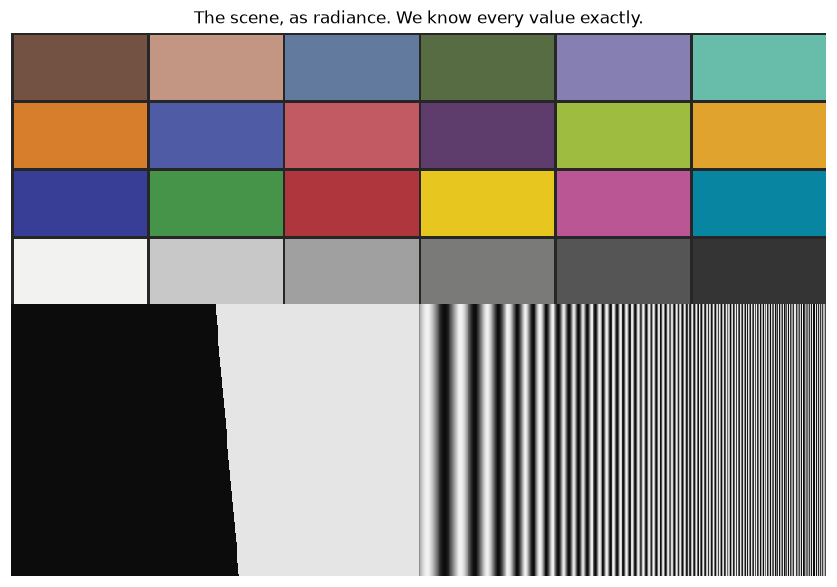

In [2]:
# The 24 patches of a standard color chart, sRGB 8-bit.
COLORCHECKER = np.array([
    [115,  82,  68], [194, 150, 130], [ 98, 122, 157], [ 87, 108,  67],
    [133, 128, 177], [103, 189, 170], [214, 126,  44], [ 80,  91, 166],
    [193,  90,  99], [ 94,  60, 108], [157, 188,  64], [224, 163,  46],
    [ 56,  61, 150], [ 70, 148,  73], [175,  54,  60], [231, 199,  31],
    [187,  86, 149], [  8, 133, 161], [243, 243, 242], [200, 200, 200],
    [160, 160, 160], [122, 122, 121], [ 85,  85,  85], [ 52,  52,  52],
], dtype=float) / 255.0


def srgb_to_linear(x):
    x = np.clip(x, 0.0, 1.0)
    return np.where(x <= 0.04045, x / 12.92, ((x + 0.055) / 1.055) ** 2.4)


def linear_to_srgb(x):
    x = np.clip(x, 0.0, 1.0)
    return np.where(x <= 0.0031308, x * 12.92, 1.055 * x ** (1 / 2.4) - 0.055)


def build_scene(h=600, w=900):
    """Scene radiance, linear, shape (h, w, 3). This is the ground truth."""
    scene = np.zeros((h, w, 3), dtype=float)

    # Top half: the 24-patch color chart, 6 across by 4 down.
    chart_h = h // 2
    for i, patch in enumerate(COLORCHECKER):
        r, c = divmod(i, 6)
        y0, y1 = r * chart_h // 4, (r + 1) * chart_h // 4
        x0, x1 = c * w // 6, (c + 1) * w // 6
        scene[y0:y1, x0:x1] = srgb_to_linear(patch)
        scene[y0:y0 + 3, x0:x1] = 0.02          # thin dark gutters, like a real chart
        scene[y0:y1, x0:x0 + 3] = 0.02

    # Bottom left: a slanted edge, about 5 degrees off vertical. Project 1 measures MTF from this.
    yy, xx = np.mgrid[chart_h:h, 0:w // 2]
    edge = (xx > (w // 4) + 0.0875 * (yy - chart_h)).astype(float)
    scene[chart_h:h, 0:w // 2] = srgb_to_linear(0.05 + 0.85 * edge)[..., None]

    # Bottom right: a frequency sweep. Period runs from 40 px down to 2 px.
    yy, xx = np.mgrid[chart_h:h, 0:w - w // 2]
    t = xx / xx.max()
    freq = 2 * np.pi * (0.025 + 0.475 * t ** 2)     # cycles per pixel, increasing
    sweep = 0.5 + 0.45 * np.sin(np.cumsum(freq, axis=1))
    scene[chart_h:h, w // 2:] = srgb_to_linear(sweep)[..., None]

    return scene


SCENE = build_scene()

plt.figure(figsize=(8, 5.4))
plt.imshow(linear_to_srgb(SCENE))
plt.title("The scene, as radiance. We know every value exactly.")
plt.axis("off"); plt.tight_layout(); plt.show()

## 2. Simulate the camera

Four stages, in the order they physically happen. Each one is irreversible.

| Stage | What it does | Lecture |
|---|---|---|
| Lens | Convolves the scene with a point spread function | 3 |
| Color filter array | Keeps one color per pixel, discards the other two | 7 |
| Sensor noise | Adds Poisson shot noise and Gaussian read noise | 5 |
| Quantization | Rounds to 12 bits over a black-to-white range | 5 |

In [3]:
BLACK_LEVEL = 256          # a typical 12-bit pedestal
WHITE_LEVEL = 4095
PSF_SIGMA   = 0.9          # pixels; a decent phone lens at a good aperture
FULL_WELL   = 9000.0       # electrons at saturation
READ_NOISE  = 2.8          # electrons RMS
# Per-channel sensor response. Real sensors are far more sensitive to green.
CHANNEL_GAIN = np.array([0.55, 1.00, 0.62])


def apply_lens(scene, sigma=PSF_SIGMA):
    """Stage 1. The PSF is a Gaussian here; lecture 3 does the real thing."""
    return cv2.GaussianBlur(scene, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)


def mosaic_rggb(rgb):
    """Stage 2. Keep one color per pixel in an RGGB pattern.

    Row 0: R G R G ...        Even row, even col -> R
    Row 1: G B G B ...        Odd  row, odd  col -> B
    """
    h, w = rgb.shape[:2]
    out = np.zeros((h, w), dtype=float)
    out[0::2, 0::2] = rgb[0::2, 0::2, 0]      # R
    out[0::2, 1::2] = rgb[0::2, 1::2, 1]      # G on red rows
    out[1::2, 0::2] = rgb[1::2, 0::2, 1]      # G on blue rows
    out[1::2, 1::2] = rgb[1::2, 1::2, 2]      # B
    return out


def expose_and_digitize(mosaic_linear, seed_rng):
    """Stages 3 and 4. Photons in, 12-bit integers out."""
    electrons = np.clip(mosaic_linear, 0, None) * FULL_WELL
    shot = seed_rng.poisson(electrons).astype(float)            # signal-dependent
    read = seed_rng.normal(0.0, READ_NOISE, electrons.shape)    # signal-independent
    signal = shot + read

    scale = (WHITE_LEVEL - BLACK_LEVEL) / FULL_WELL
    dn = BLACK_LEVEL + signal * scale
    return np.clip(np.round(dn), 0, WHITE_LEVEL).astype(np.uint16)


blurred = apply_lens(SCENE)
sensor_linear = blurred * CHANNEL_GAIN          # spectral sensitivity, crudely
RAW = expose_and_digitize(mosaic_rggb(sensor_linear), rng)

print(f"RAW is a single-channel {RAW.dtype} array, {RAW.shape[1]} x {RAW.shape[0]}")
print(f"values {RAW.min()} to {RAW.max()}, black level {BLACK_LEVEL}, white level {WHITE_LEVEL}")
print("\nThis is everything the camera actually recorded.")

RAW is a single-channel uint16 array, 900 x 600
values 256 to 3845, black level 256, white level 4095

This is everything the camera actually recorded.


## 3. What the sensor really measured

Zoom in far enough and the Bayer pattern is visible. Every pixel holds one number. The
checkerboard is not noise; it is the color filter array.

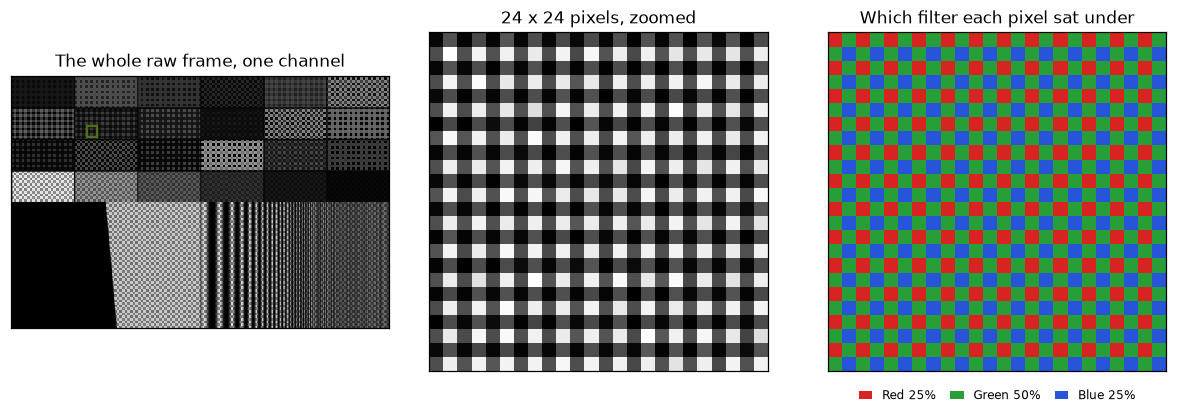

Two thirds of every color image is interpolated. That interpolation is Project 2.


In [4]:
y0, x0, n = 120, 180, 24          # a patch inside a colored square
crop = RAW[y0:y0 + n, x0:x0 + n]

# Key colors for the three filter types. A Bayer CFA has red, green, and blue
# filters and nothing else.
FILTER_R = (0.85, 0.14, 0.14)
FILTER_G = (0.16, 0.62, 0.22)
FILTER_B = (0.16, 0.33, 0.85)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))

axes[0].imshow(RAW, cmap="gray", vmin=BLACK_LEVEL, vmax=WHITE_LEVEL)
axes[0].add_patch(plt.Rectangle((x0, y0), n, n, fill=False, ec=PSU_GREEN, lw=1.5))
axes[0].set_title("The whole raw frame, one channel")

axes[1].imshow(crop, cmap="gray")
axes[1].set_title(f"{n} x {n} pixels, zoomed")

# Same crop, colored by which filter each pixel sat under. This panel is a
# categorical key, not data. Scaling the key colors by each pixel's measured
# value renders the weakest channel black, and no CFA has a black filter; the
# measured values are the panel immediately to the left.
rgb_key = np.zeros((n, n, 3))
rgb_key[0::2, 0::2] = FILTER_R
rgb_key[0::2, 1::2] = FILTER_G
rgb_key[1::2, 0::2] = FILTER_G
rgb_key[1::2, 1::2] = FILTER_B
axes[2].imshow(rgb_key)
axes[2].set_title("Which filter each pixel sat under")
axes[2].legend(
    handles=[plt.Rectangle((0, 0), 1, 1, facecolor=c)
             for c in (FILTER_R, FILTER_G, FILTER_B)],
    labels=["Red 25%", "Green 50%", "Blue 25%"],
    loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3,
    frameon=False, fontsize=8, handlelength=1.1, columnspacing=1.2,
)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print("Two thirds of every color image is interpolated. That interpolation is Project 2.")

## 4. A minimal image signal processor

Five stages, about thirty lines. A shipping ISP has tens of stages and a team tuning them,
but the shape is this.

Note the demosaic call. OpenCV's Bayer constants are named for the *second* row and column,
so an RGGB sensor needs `COLOR_BayerBG2BGR`. Getting this wrong swaps red and blue, and it is
the single most common bug in student ISP code. We will meet it again in week 4.

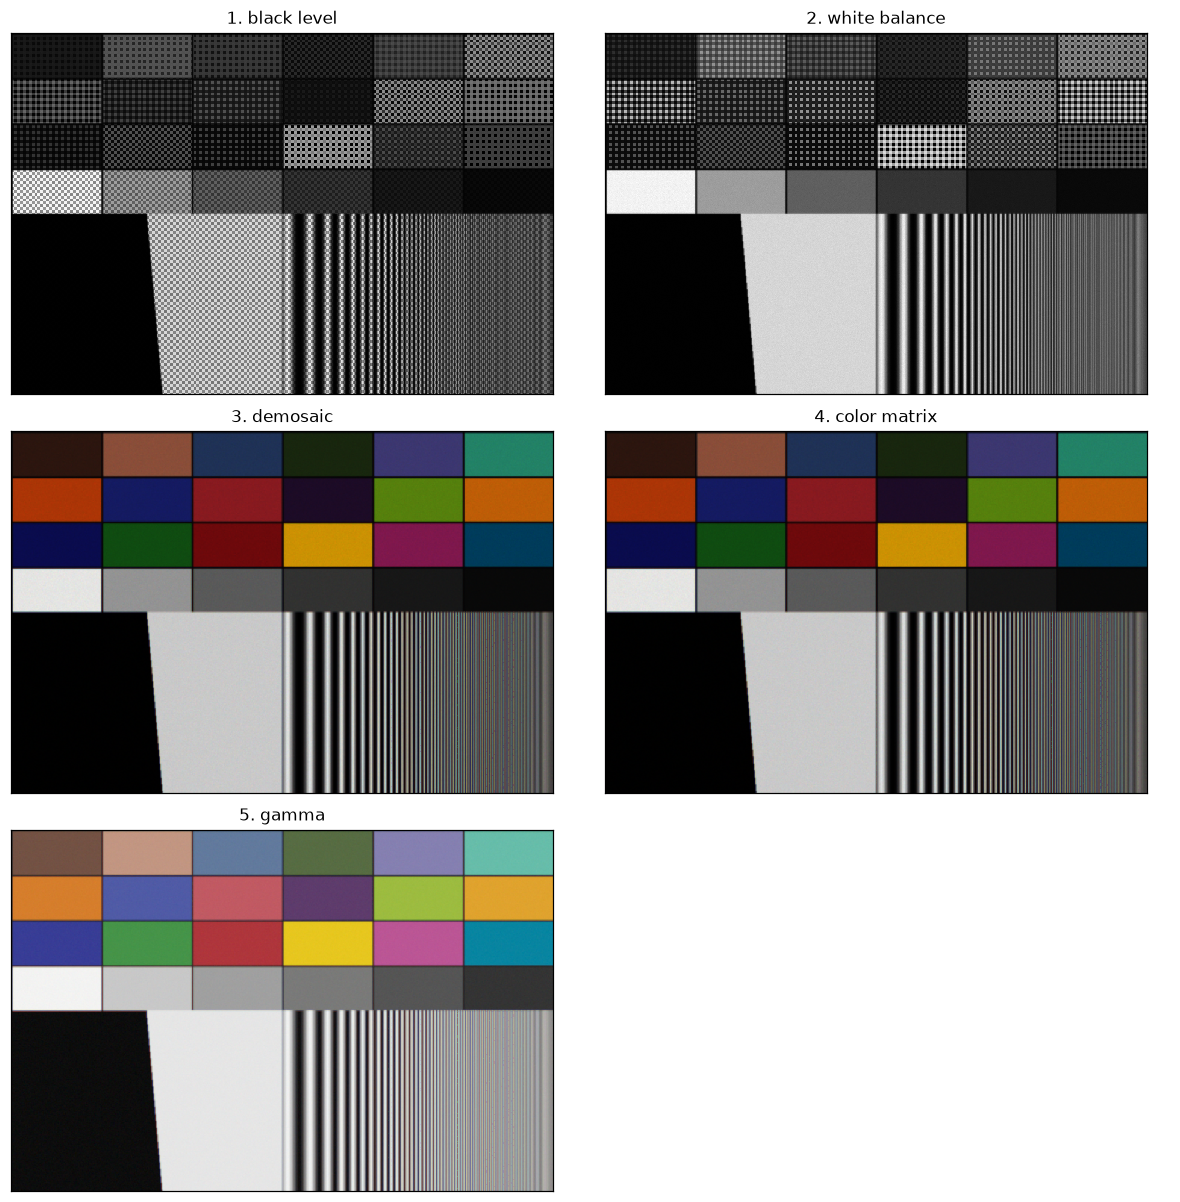

In [5]:
def isp(raw, black=BLACK_LEVEL, white=WHITE_LEVEL, wb_gains=(1 / 0.55, 1.0, 1 / 0.62),
        ccm=None, demosaic_flag=cv2.COLOR_BayerBG2BGR_EA, gamma=True):
    """Raw 12-bit Bayer in, display-referred RGB out. Returns every stage."""
    stages = {}

    # 1. Black level and normalize to [0, 1].
    x = (raw.astype(float) - black) / (white - black)
    x = np.clip(x, 0.0, 1.0)
    stages["1. black level"] = x.copy()

    # 2. White balance, applied in the mosaic before interpolation.
    gains = np.asarray(wb_gains, dtype=float)
    wb = x.copy()
    wb[0::2, 0::2] *= gains[0]      # R
    wb[0::2, 1::2] *= gains[1]      # G
    wb[1::2, 0::2] *= gains[1]      # G
    wb[1::2, 1::2] *= gains[2]      # B
    wb = np.clip(wb, 0.0, 1.0)
    stages["2. white balance"] = wb.copy()

    # 3. Demosaic. OpenCV wants 8- or 16-bit integers here.
    as_u16 = np.round(wb * 65535).astype(np.uint16)
    bgr = cv2.demosaicing(as_u16, demosaic_flag).astype(float) / 65535.0
    rgb = bgr[..., ::-1].copy()
    stages["3. demosaic"] = rgb.copy()

    # 4. Color correction matrix. Identity unless one is supplied; lecture 6 fits a real one.
    if ccm is not None:
        rgb = np.clip(rgb @ np.asarray(ccm, dtype=float).T, 0.0, 1.0)
    stages["4. color matrix"] = rgb.copy()

    # 5. Transfer function. Without this the image looks far too dark.
    out = linear_to_srgb(rgb) if gamma else rgb
    stages["5. gamma"] = out.copy()

    return out, stages


OUTPUT, STAGES = isp(RAW)

# Two columns, three rows. Five stages leave the sixth panel empty.
# The panels have to be large enough to see the Bayer checkerboard in stages 1 and 2.
fig, axes = plt.subplots(3, 2, figsize=(11, 11))
panels = axes.ravel()
for ax, (name, img) in zip(panels, STAGES.items()):
    ax.imshow(np.clip(img, 0, 1), cmap=None if img.ndim == 3 else "gray")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
for ax in panels[len(STAGES):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Two renderings, neither of them correct

The left image is the ISP above, aiming at accuracy. The right is the same data pushed the way
a phone would push it: more contrast, more saturation, more sharpening. Most people prefer the
right one. A measurement system wants neither.

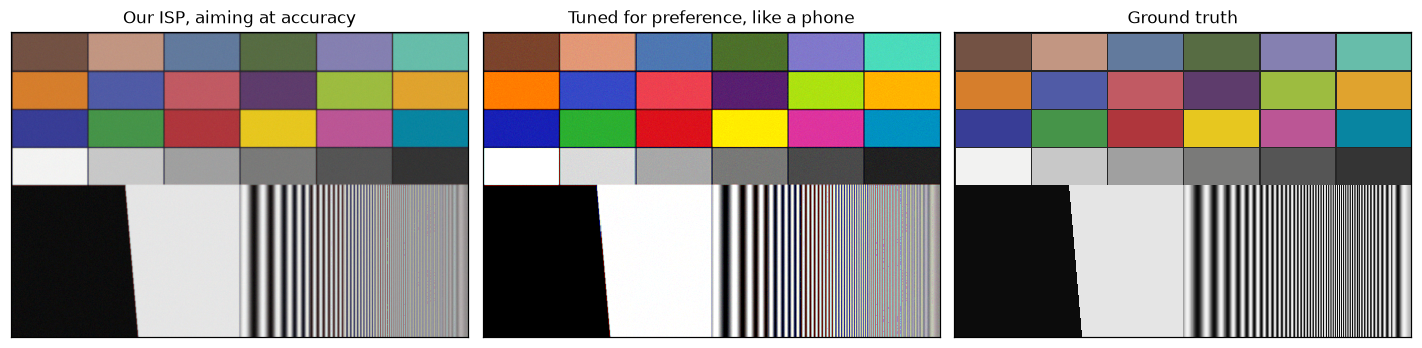

In [6]:
def preference_tune(img, contrast=1.25, saturation=1.35, sharpen=0.6):
    """A crude imitation of consumer ISP taste. Lecture 7 covers what really happens."""
    x = np.clip(img, 0, 1)
    x = np.clip(0.5 + contrast * (x - 0.5), 0, 1)                 # S-curve, roughly
    gray = x.mean(axis=2, keepdims=True)
    x = np.clip(gray + saturation * (x - gray), 0, 1)             # saturation
    blur = cv2.GaussianBlur(x, (0, 0), 1.2)
    return np.clip(x + sharpen * (x - blur), 0, 1)                # unsharp mask


TUNED = preference_tune(OUTPUT)
TRUTH = linear_to_srgb(SCENE)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
for ax, img, title in zip(
    axes, [OUTPUT, TUNED, TRUTH],
    ["Our ISP, aiming at accuracy", "Tuned for preference, like a phone", "Ground truth"]
):
    ax.imshow(img); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. What it cost

Now the part you cannot do with a real photograph. We know the true scene, so we can measure
the error exactly.

RMSE against the truth, our ISP        0.1121
RMSE against the truth, preference ISP 0.1354

The rendering people prefer is measurably further from the scene.


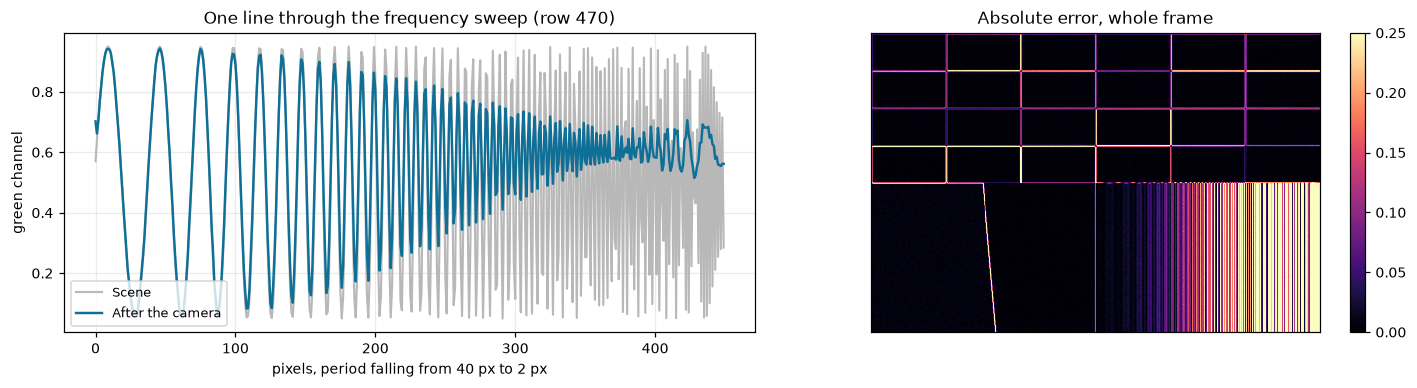

Detail survives on the left of the sweep and is gone on the right. The lens removed it
and no amount of processing brings it back. Where the sweep is finest, the camera even
reports structure that is not in the scene. That is aliasing, and it is lecture 9.


In [7]:
def rmse(a, b):
    return float(np.sqrt(np.mean((np.clip(a, 0, 1) - np.clip(b, 0, 1)) ** 2)))


print(f"RMSE against the truth, our ISP        {rmse(OUTPUT, TRUTH):.4f}")
print(f"RMSE against the truth, preference ISP {rmse(TUNED,  TRUTH):.4f}")
print("\nThe rendering people prefer is measurably further from the scene.")

row = 470                                   # a line through the frequency sweep
w2 = SCENE.shape[1] // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})

axes[0].plot(TRUTH[row, w2:, 1],  color="#b8b8b8", lw=1.4, label="Scene")
axes[0].plot(OUTPUT[row, w2:, 1], color=PSU_BLUE,  lw=1.6, label="After the camera")
axes[0].set_title(f"One line through the frequency sweep (row {row})")
axes[0].set_xlabel("pixels, period falling from 40 px to 2 px")
axes[0].set_ylabel("green channel")
axes[0].legend(loc="lower left", fontsize=8.5)
axes[0].grid(alpha=.25)

err = np.abs(OUTPUT - TRUTH).mean(axis=2)
im = axes[1].imshow(err, cmap="magma", vmin=0, vmax=0.25)
axes[1].set_title("Absolute error, whole frame")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1], fraction=0.035)
plt.tight_layout(); plt.show()

print("Detail survives on the left of the sweep and is gone on the right. The lens removed it")
print("and no amount of processing brings it back. Where the sweep is finest, the camera even")
print("reports structure that is not in the scene. That is aliasing, and it is lecture 9.")

## 7. The demosaic choice, if there is time

Same raw data, two interpolation methods. Bilinear is what you would write first; the
edge-aware version is closer to what ships. Look along the slanted edge for the colored fringes
that give demosaicing artifacts their name.

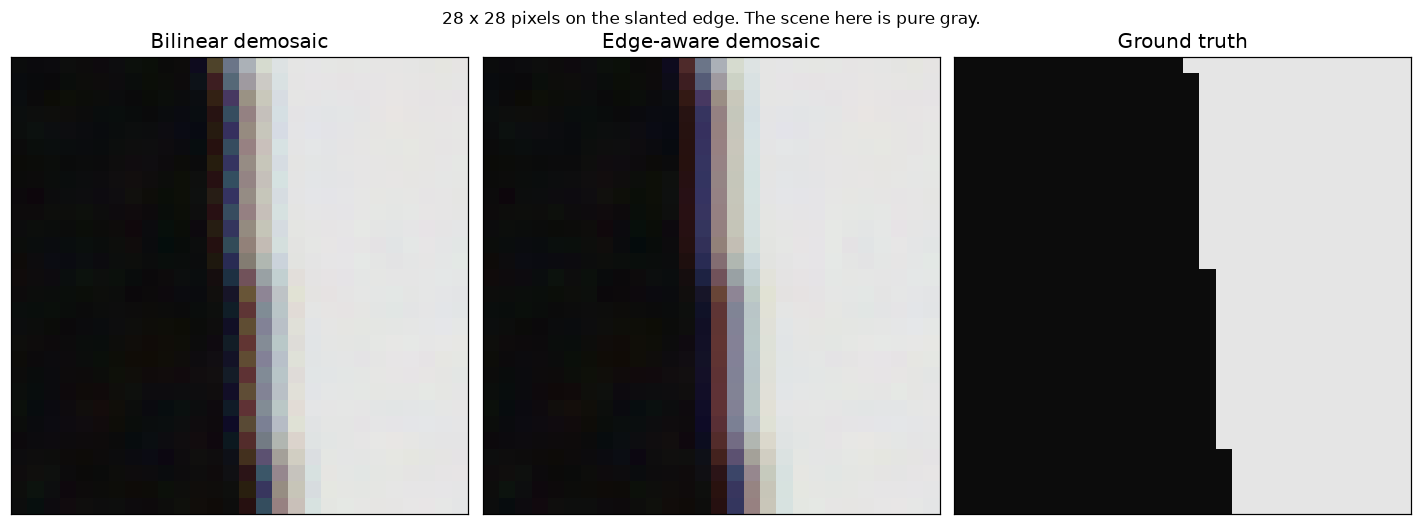

RMSE bilinear    0.1142
RMSE edge-aware  0.1121

One line of the pipeline changed. Nothing else.


In [13]:
bilinear, _ = isp(RAW, demosaic_flag=cv2.COLOR_BayerBG2BGR)
edge_aware   = OUTPUT
TRUTH        = linear_to_srgb(SCENE)

# A tight window on the slanted edge, centered on the strongest false color in the
# frame. Small and blown up on purpose: the fringes are one to two pixels wide, so
# a wider crop shows them at a size no projector can resolve.
ry, rx, rn = 505, 229, 28

fig, axes = plt.subplots(1, 3, figsize=(13, 4.9))
for ax, img, title in zip(
    axes, [bilinear, edge_aware, TRUTH],
    ["Bilinear demosaic", "Edge-aware demosaic", "Ground truth"]
):
    ax.imshow(np.clip(img[ry:ry + rn, rx:rx + rn], 0, 1))
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{rn} x {rn} pixels on the slanted edge. The scene here is pure gray.",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"RMSE bilinear    {rmse(bilinear,   TRUTH):.4f}")
print(f"RMSE edge-aware  {rmse(edge_aware, TRUTH):.4f}")
print("\nOne line of the pipeline changed. Nothing else.")

## 8. With a real raw file

Everything above is a simulation, which is what let us measure the error. Swap in a real
capture to show that the same five stages apply, and that the numbers coming off a real sensor
look exactly like the ones we just made up.

Drop a raw file into the  folder beside the slides and run this.

**It has to be a Bayer mosaic.** A JPEG or HEIC is the ISP's output, not its input. Apple
ProRAW is closer but still not it: the phone demosaics, denoises, and fuses first, then writes
a *linear* DNG, so stages 1 through 4 have already happened. The cell below detects both cases
and says so rather than failing. For a true mosaic, use a non-ProRAW raw app, a Raspberry Pi HQ
camera, or any interchangeable-lens camera.

629B07DB-3DEE-4FD7-91A5-46EB54BDCC4A.DNG: raw_image (3024, 4032), RawType.Flat, black 528, white 4095
Bayer mosaic, CFA BGGR. White balance gains [2.13, 1.0, 2.22]


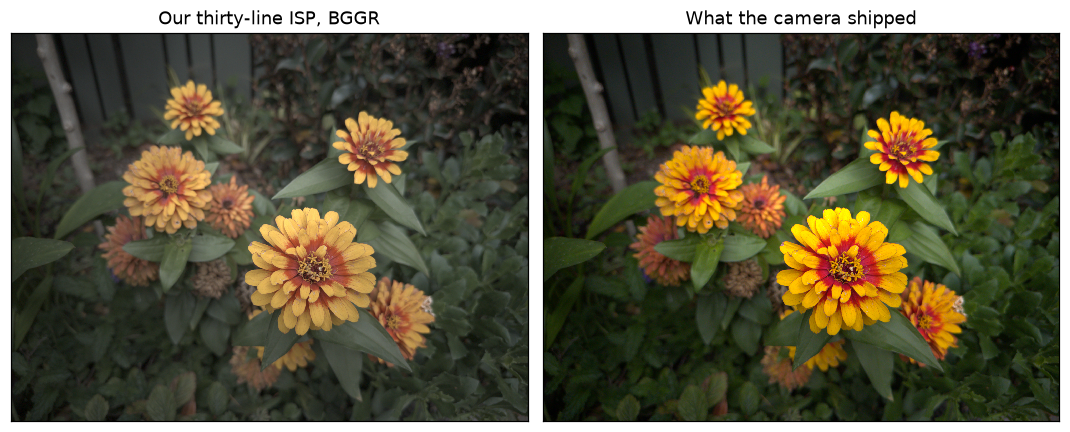


The camera's version is better, and that difference is eight weeks of this course.


In [15]:
from pathlib import Path

RAW_SUFFIXES = {".dng", ".arw", ".cr2", ".cr3", ".nef", ".raf", ".orf", ".rw2"}
PROCESSED    = {".jpg", ".jpeg", ".heic", ".heif", ".png", ".tif", ".tiff"}

# OpenCV names its Bayer constants for the 2x2 block at row 1, column 1, not the
# one at the origin, so the name is the sensor's bottom-right pixel followed by
# its bottom-left. An RGGB sensor is COLOR_BayerBG. Choose the wrong one and red
# and blue swap: orange flowers come out blue. Never hard-code this for a real
# file. The sensor tells you its layout and iPhones are not RGGB.
OPENCV_BAYER = {
    "RGGB": cv2.COLOR_BayerBG2BGR_EA,
    "BGGR": cv2.COLOR_BayerRG2BGR_EA,
    "GRBG": cv2.COLOR_BayerGB2BGR_EA,
    "GBRG": cv2.COLOR_BayerGR2BGR_EA,
}


def find_images_dir():
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        if (parent / "Images").is_dir():
            return parent / "Images"
    return None


images = find_images_dir()
files  = sorted(images.rglob("*")) if images else []
raws   = [p for p in files if p.suffix.lower() in RAW_SUFFIXES]
others = [p for p in files if p.suffix.lower() in PROCESSED]

if not raws:
    print("No raw file found under an Images/ folder. The simulation above stands on its own.")
    for p in others:
        print(f"  {p.name} cannot be used. It is the ISP's output, not its input.")
    print("Put a raw file there before lecture and this cell will use it.")
else:
    import rawpy
    path = raws[0]
    with rawpy.imread(str(path)) as raw:
        sensor  = raw.raw_image_visible.copy()
        kind    = raw.raw_type
        pattern = raw.raw_pattern
        desc    = raw.color_desc.decode()
        black   = float(np.mean(raw.black_level_per_channel))
        white   = float(raw.white_level)
        wb      = np.array(raw.camera_whitebalance, dtype=float)
        shipped = raw.postprocess(use_camera_wb=True, output_bps=8, half_size=True)

    # LibRaw reports the CFA as indices into color_desc, so "RGBG" with pattern
    # [[2, 3], [1, 0]] means the top-left 2x2 reads B G / G R.
    cfa = "".join(desc[i] for i in pattern.flatten()) if pattern is not None else None
    is_mosaic = sensor.ndim == 2 and cfa in OPENCV_BAYER

    print(f"{path.name}: raw_image {sensor.shape}, {kind}, black {black:.0f}, white {white:.0f}")

    if is_mosaic:
        # isp() applies wb_gains[0] at (0,0), [1] at both greens and [2] at (1,1),
        # so place the camera's red and blue gains by this sensor's actual layout.
        per_color = {"R": wb[0] / wb[1], "G": 1.0, "B": wb[2] / wb[1]}
        gains = (per_color[cfa[0]], 1.0, per_color[cfa[3]])
        print(f"Bayer mosaic, CFA {cfa}. White balance gains {np.round(gains, 2).tolist()}")
        mine, _ = isp(sensor, black=black, white=white, wb_gains=gains,
                      demosaic_flag=OPENCV_BAYER[cfa])
        panels = [(mine, f"Our thirty-line ISP, {cfa}"),
                  (shipped / 255.0, "What the camera shipped")]
        note = "The camera's version is better, and that difference is eight weeks of this course."
    else:
        print()
        print("This is not a Bayer mosaic, so our ISP has nothing to demosaic.")
        print("Apple ProRAW and several other computational cameras demosaic, denoise,")
        print("and fuse on the phone, then write the result back as a linear DNG.")
        print(f"  raw_image is {sensor.ndim}-dimensional, CFA pattern {cfa}")
        print(f"  black level {black:.0f}, white balance {wb[:3].tolist()}, both already applied")
        print("For a real mosaic, capture with an app that writes Bayer raw rather than")
        print("ProRAW, or use a Raspberry Pi HQ or interchangeable-lens camera.")
        print()
        print("It is still linear, which is what stage 5 exists to fix:")
        lin = (sensor[..., :3].astype(float) / white)[::8, ::8]
        panels = [(lin, "Linear, as stored in the DNG"),
                  (linear_to_srgb(lin), "After the sRGB transfer function"),
                  (shipped / 255.0, "What the camera shipped")]
        note = "Same data. The only difference on the left two panels is one transfer function."

    fig, axes = plt.subplots(1, len(panels), figsize=(4.9 * len(panels), 4.6))
    for ax, (img, title) in zip(np.atleast_1d(axes), panels):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

    print("\n" + note)

## Back to the slides

Land on this: an image is the output of a physical instrument, every stage of that instrument
discards something, and most of what people call camera quality is software written by people
who made choices. Weeks 1 through 5 take that pipeline apart one box at a time. Weeks 6 through
10 try to run it backwards.

Next lecture is *Derive* tier: geometric image formation and calibration. Tell them to bring paper.